In [6]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [13]:
# Clone directly from GitHub so we get the new 256 bottleneck update automatically!
!git clone https://github.com/JasonHertzog/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data.git

# Enter the project directory
%cd CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data

Cloning into 'CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 478 (delta 17), reused 19 (delta 11), pack-reused 437 (from 1)
Receiving objects: 100% (478/478), 26.70 MiB | 31.57 MiB/s, done.
Resolving deltas: 100% (266/266), done.
/content/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data


In [15]:
!python scripts/download_data.py
!mkdir -p data/raw/utkface
!tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface
!tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface
!tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface
!python -m scripts.preprocess_data

Starting part1.tar.gz (833.4 MB) from the official UTKFace source...
Saved part1.tar.gz to /content/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Starting part2.tar.gz (437.3 MB) from the official UTKFace source...
Saved part2.tar.gz to /content/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Starting part3.tar.gz (54.3 MB) from the official UTKFace source...
Saved part3.tar.gz to /content/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.
Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('3

In [16]:
import yaml, pathlib

config_frozen = {
    "experiment_name": "mlp_dropout_frozen_256",
    "model_name": "mlp_dropout",
    "seed": 42,
    "pretrained": True,
    "freeze_backbone": True,
    "task": "regression",
    "metric": "mae",
    "batch_size": 32,
    "num_workers": 2,
    "image_size": 224,
    "epochs": 30,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "save_best": True,
    "dropout": 0.2,
    "weight_decay": 0.0,
}

config_finetuned = {
    "experiment_name": "mlp_dropout_finetuned_256",
    "model_name": "mlp_dropout",
    "seed": 42,
    "pretrained": True,
    "freeze_backbone": False,
    "task": "regression",
    "metric": "mae",
    "batch_size": 32,
    "num_workers": 2,
    "image_size": 224,
    "epochs": 30,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "save_best": True,
    "dropout": 0.2,
    "weight_decay": 0.0,
}

# Create the config files
pathlib.Path("configs").mkdir(exist_ok=True)
with open("configs/mlp_dropout_frozen_256.yaml", "w") as f: yaml.dump(config_frozen, f)
with open("configs/mlp_dropout_finetuned_256.yaml", "w") as f: yaml.dump(config_finetuned, f)

print("Configs generated successfully!")

Configs generated successfully!


In [17]:
!PYTHONPATH=/content/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data \
  python scripts/train.py --config configs/mlp_dropout_frozen_256.yaml

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 258MB/s]
Using Adam optimizer without weight decay
Setup complete! Ready to begin training epochs.
100% 602/602 [00:21<00:00, 27.92it/s, loss=247]
100% 76/76 [00:02<00:00, 33.01it/s, loss=180]
Epoch [1/30] Train Loss: 247.4495, Train MAE: 11.9034, Train MSE: 247.4495, Train Acc@3: 0.1806, Train Acc@5: 0.2917 | Val Loss: 180.0542, Val MAE: 9.8987, Val MSE: 180.0542, Val Acc@3: 0.2253, Val Acc@5: 0.3402, Val MAE: 9.8987
100% 602/602 [00:21<00:00, 28.56it/s, loss=182]
100% 76/76 [00:02<00:00, 33.00it/s, loss=165]
Epoch [2/30] Train Loss: 182.0107, Train MAE: 10.2175, Train MSE: 182.0107, Train Acc@3: 0.2090, Train Acc@5: 0.3374 | Val Loss: 164.9389, Val MAE: 9.5176, Val MSE: 164.9389, Val Acc@3: 0.2423, Val Acc@5: 0.3710, Val MAE: 9.5176
100%

In [18]:
!PYTHONPATH=/content/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data \
  python scripts/train.py --config configs/mlp_dropout_finetuned_256.yaml

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using Adam optimizer without weight decay
Setup complete! Ready to begin training epochs.
100% 602/602 [00:20<00:00, 28.83it/s, loss=207]
100% 76/76 [00:02<00:00, 32.82it/s, loss=162]
Epoch [1/30] Train Loss: 206.7875, Train MAE: 10.5896, Train MSE: 206.7875, Train Acc@3: 0.2107, Train Acc@5: 0.3410 | Val Loss: 162.0530, Val MAE: 9.5120, Val MSE: 162.0530, Val Acc@3: 0.2452, Val Acc@5: 0.3880, Val MAE: 9.5120
100% 602/602 [00:21<00:00, 28.55it/s, loss=140]
100% 76/76 [00:02<00:00, 32.82it/s, loss=138]
Epoch [2/30] Train Loss: 140.4801, Train MAE: 8.6718, Train MSE: 140.4801, Train Acc@3: 0.2644, Train Acc@5: 0.4109 | Val Loss: 138.4502, Val MAE: 8.5632, Val MSE: 138.4502, Val Acc@3: 0.2855, Val Acc@5: 0.4257, Val MAE: 8.5632
100% 602/602 [00:21<00:00, 28.50it/s, loss=123]
100% 76/76 [00:02<00:00, 32.81it/s, loss=103]
Epoch [3/30] Train Loss: 123.0898, Train MAE: 8.0952, Train MSE: 123.0898, Train Acc

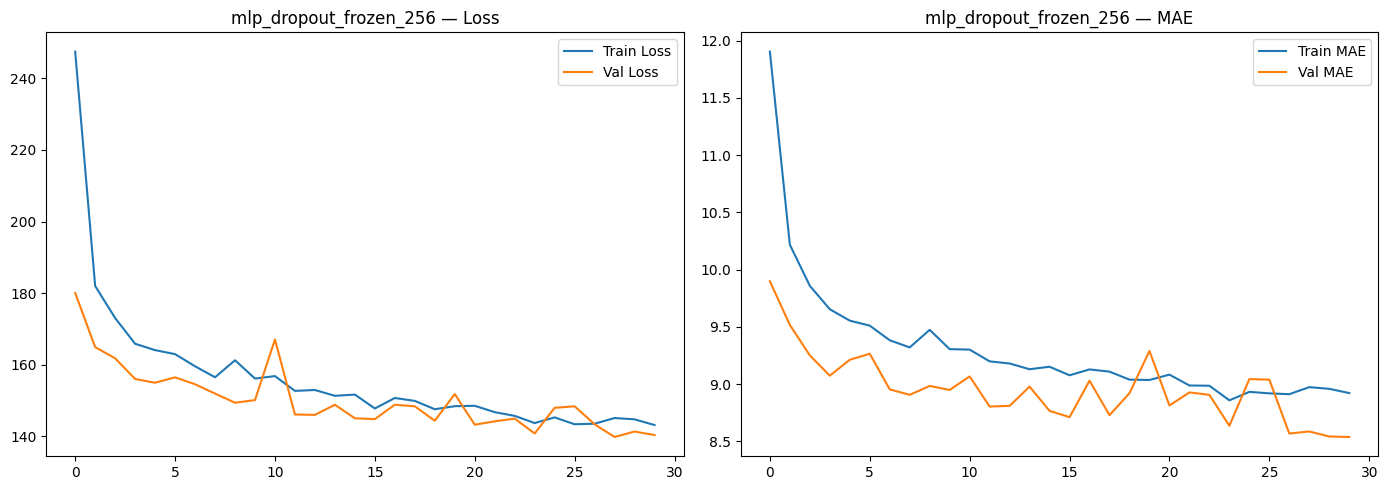

mlp_dropout_frozen_256: Best Val MAE = 8.5392


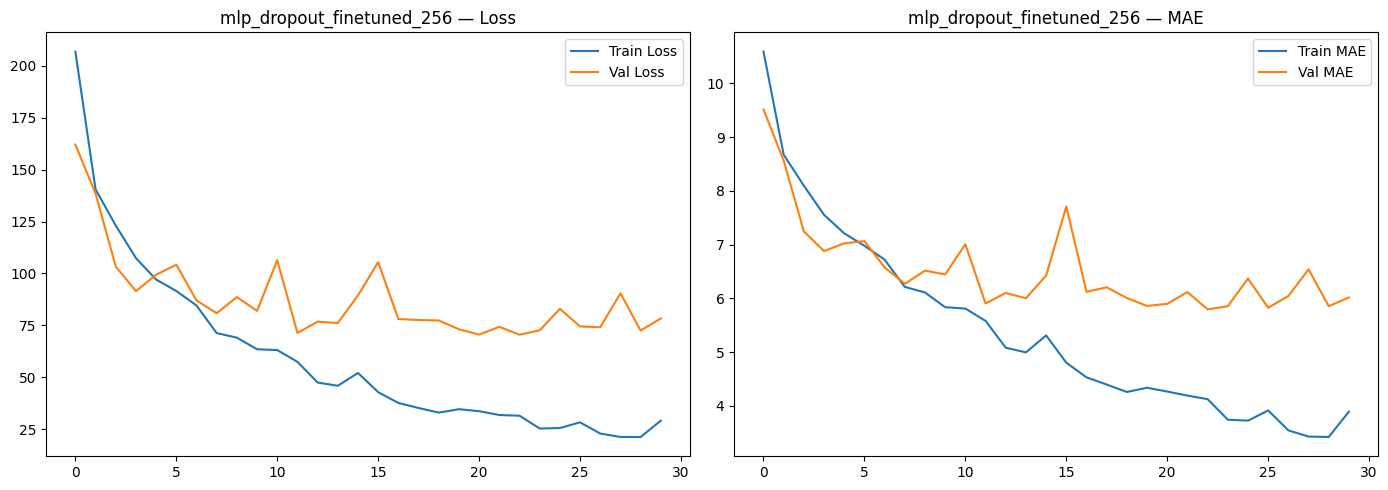

mlp_dropout_finetuned_256: Best Val MAE = 5.7946


In [19]:
import numpy as np
import matplotlib.pyplot as plt

experiments = ["mlp_dropout_frozen_256", "mlp_dropout_finetuned_256"]

for exp_name in experiments:
    stats = np.load(f"outputs/stats_history_{exp_name}.npy", allow_pickle=True).item()
    train_maes = [s["mae"] for s in stats["train"]]
    val_maes   = [s["mae"] for s in stats["eval"]]
    train_losses = [s["loss"] for s in stats["train"]]
    val_losses   = [s["loss"] for s in stats["eval"]]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(train_losses, label="Train Loss")
    ax1.plot(val_losses,   label="Val Loss")
    ax1.set_title(f"{exp_name} — Loss")
    ax1.legend()

    ax2.plot(train_maes, label="Train MAE")
    ax2.plot(val_maes,   label="Val MAE")
    ax2.set_title(f"{exp_name} — MAE")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"outputs/experiment_curves_{exp_name}.png")
    plt.show()
    print(f"{exp_name}: Best Val MAE = {min(val_maes):.4f}")

In [20]:
from google.colab import files

# Zip the entire outputs directory
!zip -r all_my_outputs.zip outputs/

# Download the unified file
files.download("all_my_outputs.zip")

  adding: outputs/ (stored 0%)
  adding: outputs/checkpoint_mlp_dropout_finetuned_256_10.pth (deflated 7%)
  adding: outputs/checkpoint_mlp_dropout_frozen_256_10.pth (deflated 7%)
  adding: outputs/README.md (deflated 13%)
  adding: outputs/stats_history_mlp_dropout_finetuned_256.npy (deflated 39%)
  adding: outputs/mlp/ (stored 0%)
  adding: outputs/mlp/mlp_frozen.ipynb (deflated 25%)
  adding: outputs/mlp/mlp_fully_finetuned.ipynb (deflated 25%)
  adding: outputs/checkpoint_mlp_dropout_frozen_256_20.pth (deflated 7%)
  adding: outputs/checkpoint_mlp_dropout_finetuned_256_30.pth (deflated 7%)
  adding: outputs/experiment_curves_mlp_dropout_finetuned_256.png (deflated 6%)
  adding: outputs/checkpoint_mlp_dropout_frozen_256_30.pth (deflated 7%)
  adding: outputs/checkpoint_mlp_dropout_finetuned_256_20.pth (deflated 7%)
  adding: outputs/experiment_curves_mlp_dropout_frozen_256.png (deflated 7%)
  adding: outputs/checkpoint_mlp_dropout_finetuned_256.pth (deflated 7%)
  adding: outputs/st

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>